# **Fundamentos de Aprendizaje por Refuerzo**

# *Double Q-Learning and SARSA*

## **Importar liberías**

In [1]:
import numpy as np
import pandas as pd
import gymnasium as gym
import random
from collections import deque
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image

## **Descripción del entorno**

Entorno obtenido de: https://www.gymlibrary.dev/environments/toy_text/taxi/

<img src="https://www.gymlibrary.dev/_images/taxi.gif" alt="QL_Algorithm" width="500"/>

**Descripción**

- Hay cuatro ubicaciones designadas en el mundo de la cuadrícula indicadas por R (rojo), G (verde), Y (amarillo) y B (azul).
- Cuando comienza el episodio, el taxi parte de una casilla aleatoria y el pasajero se encuentra en una ubicación aleatoria.
- El taxi se dirige a la ubicación del pasajero, lo recoge, conduce al destino del pasajero (otro de los cuatro lugares especificados) y luego lo deja.
- Una vez que se deja al pasajero, el episodio termina.

**Acciones**

- 0: moverse hacia el sur
- 1: moverse hacia el norte
- 2: moverse hacia el este
- 3: moverse hacia el oeste
- 4: pasajero de recogida
- 5: dejar pasajero

## **Crear y observar el ambiente (estados y acciones)**

In [2]:
env = gym.make('Taxi-v3',render_mode="rgb_array")
num_states = env.observation_space.n
num_actions = env.action_space.n
print("Número de estados:", num_states)
print("Número de acciones:", num_actions)

Número de estados: 500
Número de acciones: 6


## **Double Q-Learning Algorithm**

#### Epsilon-Greedy Policy to Double Q-Learning

<img src="https://raw.githubusercontent.com/cdavid2804/test-1/main/epsilon_greedy_DDQL.png" width="500"/>

#### Double Q-learning Algorithm


<img src="https://raw.githubusercontent.com/cdavid2804/test-1/main/DDQL.png" alt="QL_Algorithm" width="700"/>

In [15]:
# Double Q-Learning Algorithm
alpha = 0.7 # taza de aprendizaje
gamma = 0.995 # factor de descuento
epsilon = 0.1
num_episodes = 1000
episode_reward = deque(maxlen=num_episodes)

Q1 = np.zeros((num_states, num_actions))
Q2 = np.zeros((num_states, num_actions))

np.random.seed(42)
def epsilon_greedy(state,epsilon):
  if np.random.rand() < epsilon:
    action = np.random.randint(num_actions)
  else:
    action = np.argmax(Q1[state,:]+Q2[state,:])
  return action

for episode in range(num_episodes):
  state, _ = env.reset()
  done = False
  total_reward  = 0
  steps = 0
  while not done:
    action = epsilon_greedy(state, epsilon)
    next_state, reward, done, _, _ = env.step(action)
    if np.random.rand() < 0.5:
      Q1[state,action] = Q1[state,action] + alpha*(reward + gamma*Q2[next_state,np.argmax(Q1[next_state,:])] - Q1[state,action])
    else:
      Q2[state,action] = Q2[state,action] + alpha*(reward + gamma*Q1[next_state,np.argmax(Q2[next_state,:])] - Q2[state,action])
    total_reward += reward
    state = next_state
    steps += 1
  episode_reward.append((episode,total_reward))
  print("Episodio:",episode," Recompensa total:", total_reward," Pasos por episodio:",steps)
Q = (Q1 + Q2)/2

Episodio: 0  Recompensa total: -3369  Pasos por episodio: 1311
Episodio: 1  Recompensa total: -563  Pasos por episodio: 314
Episodio: 2  Recompensa total: -589  Pasos por episodio: 286
Episodio: 3  Recompensa total: -815  Pasos por episodio: 368
Episodio: 4  Recompensa total: -1037  Pasos por episodio: 473
Episodio: 5  Recompensa total: -676  Pasos por episodio: 301
Episodio: 6  Recompensa total: -2033  Pasos por episodio: 731
Episodio: 7  Recompensa total: -987  Pasos por episodio: 387
Episodio: 8  Recompensa total: -2060  Pasos por episodio: 1001
Episodio: 9  Recompensa total: -2345  Pasos por episodio: 1061
Episodio: 10  Recompensa total: -3140  Pasos por episodio: 1289
Episodio: 11  Recompensa total: -1274  Pasos por episodio: 575
Episodio: 12  Recompensa total: -3312  Pasos por episodio: 1407
Episodio: 13  Recompensa total: -1122  Pasos por episodio: 513
Episodio: 14  Recompensa total: -67  Pasos por episodio: 52
Episodio: 15  Recompensa total: -220  Pasos por episodio: 88
Episodi

### **Gráfica: recompensa total y la recompensa promedio**

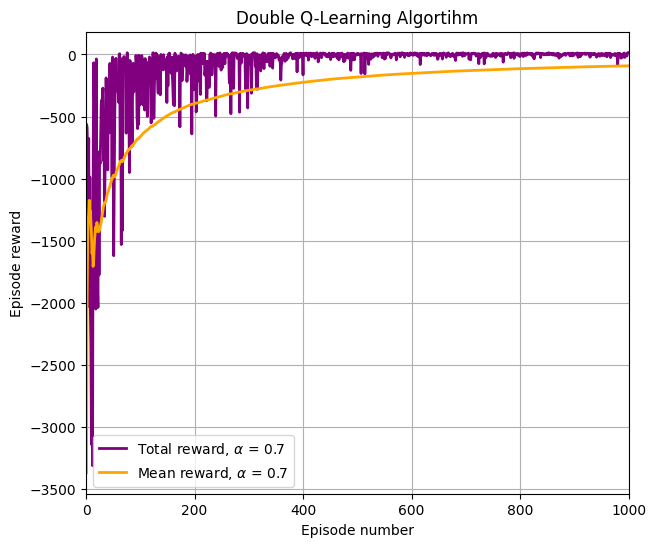

In [16]:
episodeReward = np.array(episode_reward)
episodes = episodeReward[:,0]

# Total rewards
rewards = episodeReward[:,1]
# Mean rewards
meanRewards = np.zeros(len(episodes))

for i in range(len(episodes)):
    if i == 0:
        meanRewards[0] = rewards[0]
    else:
        meanRewards[i] = np.mean(rewards[:i])

plt.figure(figsize=(7, 6))
plt.plot(episodes, rewards, label=r"Total reward, $\alpha$ = "+str(alpha), linewidth=2, color='purple')
plt.plot(episodes, meanRewards, label=r"Mean reward, $\alpha$ = "+str(alpha), linewidth=2, color='orange')
plt.xlabel("Episode number")
plt.ylabel("Episode reward")
plt.title("Double Q-Learning Algortihm")
plt.xlim(0, num_episodes)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10)
plt.grid()
plt.legend()
plt.show()

#### **Probar la política entrenada**

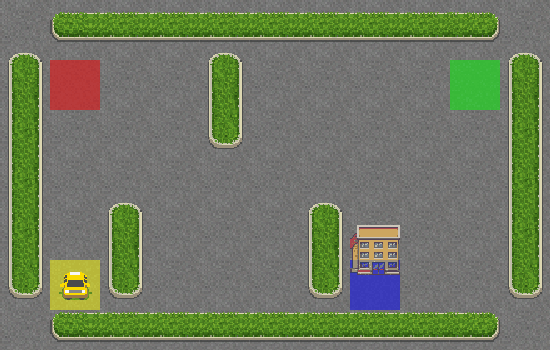

In [18]:
env = gym.make('Taxi-v3', render_mode="rgb_array")
state, _ = env.reset()
done = False
frames = []
for i in range(30):
    action = np.argmax(Q[state,:])  # Elegir la mejor acción según la tabla Q
    next_state, _, _, _, _ = env.step(action)
    frame = env.render()
    frames.append(frame)
    state = next_state
env.close()
imageio.mimsave('taxi_test_DQL.gif', frames, fps=3)
Image(filename='taxi_test_DQL.gif')

## **SARSA Algorithm**

***SARSA Algorithm***


<img src="https://raw.githubusercontent.com/cdavid2804/test-1/main/SARSA.png" width="600"/>



In [6]:
# SARSA Algorithm
alpha = 0.8 # taza de aprendizaje
gamma = 0.995 # factor de descuento
epsilon = 0.1
num_episodes = 1000
episode_reward = deque(maxlen=num_episodes)

Q = np.zeros((num_states, num_actions))
np.random.seed(42)
def epsilon_greedy(state,epsilon):
  if np.random.rand() < epsilon:
    action = np.random.randint(num_actions)
  else:
    action = np.argmax(Q[state,:])
  return action

for episode in range(num_episodes):
  state, _ = env.reset()
  action = epsilon_greedy(state, epsilon)
  done = False
  total_reward  = 0
  steps = 0
  while not done:
    next_state, reward, done, _, _ = env.step(action)
    next_action = epsilon_greedy(next_state, epsilon)
    Q[state,action] = Q[state,action] + alpha*(reward + gamma*Q[next_state, next_action] - Q[state,action])
    total_reward += reward
    state = next_state
    action = next_action
    steps += 1
  episode_reward.append((episode,total_reward))
  print("Episodio:",episode," Recompensa total:", total_reward," Pasos por episodio:",steps)

Episodio: 0  Recompensa total: -1083  Pasos por episodio: 348
Episodio: 1  Recompensa total: -706  Pasos por episodio: 241
Episodio: 2  Recompensa total: -4675  Pasos por episodio: 1645
Episodio: 3  Recompensa total: -3235  Pasos por episodio: 1033
Episodio: 4  Recompensa total: -721  Pasos por episodio: 265
Episodio: 5  Recompensa total: -448  Pasos por episodio: 262
Episodio: 6  Recompensa total: -2839  Pasos por episodio: 1150
Episodio: 7  Recompensa total: -2873  Pasos por episodio: 1832
Episodio: 8  Recompensa total: -1490  Pasos por episodio: 593
Episodio: 9  Recompensa total: -152  Pasos por episodio: 137
Episodio: 10  Recompensa total: -458  Pasos por episodio: 236
Episodio: 11  Recompensa total: -263  Pasos por episodio: 221
Episodio: 12  Recompensa total: -177  Pasos por episodio: 117
Episodio: 13  Recompensa total: -981  Pasos por episodio: 408
Episodio: 14  Recompensa total: -3629  Pasos por episodio: 1265
Episodio: 15  Recompensa total: -2813  Pasos por episodio: 1808
Epis

### **Gráfica: recompensa total y la recompensa promedio**

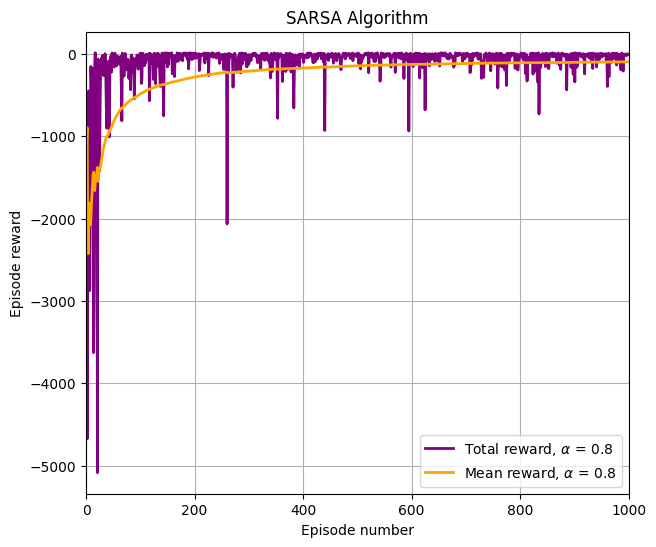

In [7]:
episodeReward = np.array(episode_reward)
episodes = episodeReward[:,0]

# Total rewards
rewards = episodeReward[:,1]
# Mean rewards
meanRewards = np.zeros(len(episodes))

for i in range(len(episodes)):
    if i == 0:
        meanRewards[0] = rewards[0]
    else:
        meanRewards[i] = np.mean(rewards[:i])

plt.figure(figsize=(7, 6))
plt.plot(episodes, rewards, label=r"Total reward, $\alpha$ = "+str(alpha), linewidth=2, color='purple')
plt.plot(episodes, meanRewards, label=r"Mean reward, $\alpha$ = "+str(alpha), linewidth=2, color='orange')
plt.xlabel("Episode number")
plt.ylabel("Episode reward")
plt.title("SARSA Algorithm")
plt.xlim(0, num_episodes)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10)
plt.grid()
plt.legend()
plt.show()

#### **Probar la política entrenada**

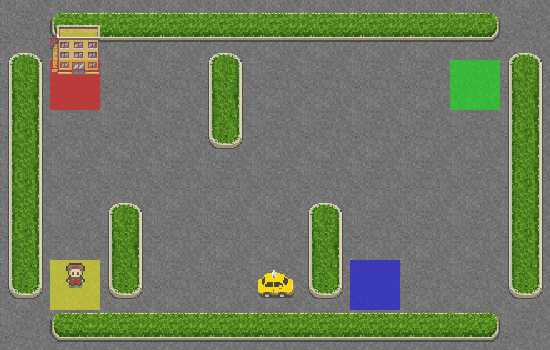

In [12]:
env = gym.make('Taxi-v3', render_mode="rgb_array")
state, _ = env.reset()
done = False
frames = []
for i in range(30):
    action = np.argmax(Q[state,:])  # Elegir la mejor acción según la tabla Q
    next_state, _, _, _, _ = env.step(action)
    frame = env.render()
    frames.append(frame)
    state = next_state
env.close()
imageio.mimsave('taxi_test_SARSA.gif', frames, fps=3)
Image(filename='taxi_test_SARSA.gif')